In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import bayesflow as bf
import keras
from bayesflow.wrappers.pymc import NeuralRatioDistribution

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import pymc as pm
import pytensor

from hssm.distribution_utils import make_distribution_for_supported_model
from ssms.basic_simulators.simulator import simulator as ssm_simulator
from ssms.config import model_config as ssms_model_config

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'
INFO:arviz:Found 'auto' as default backend, checking available backends
INFO:arviz:Matplotlib is available, defining as default backend
INFO:arviz.preview:arviz_base available, exposing its functions as part of arviz.preview
INFO:arviz.preview:arviz_stats available, exposing its functions as part of arviz.preview
INFO:arviz.preview:arviz_plots available, exposing its functions as part of arviz.preview


# Model Setup: DDM Configuration

In [2]:
# Read DDM config from ssm-simulators
ddm_cfg = ssms_model_config["ddm"]
param_names = ddm_cfg["params"]
param_lower = np.array(ddm_cfg["param_bounds"][0])
param_upper = np.array(ddm_cfg["param_bounds"][1])
param_defaults = np.array(ddm_cfg["default_params"])

print("DDM parameters:")
for name, lo, hi, default in zip(param_names, param_lower, param_upper, param_defaults):
    print(f"  {name:5s}: bounds=[{lo:5.2f}, {hi:5.2f}], default={default}")

DDM parameters:
  v    : bounds=[-3.00,  3.00], default=0.0
  a    : bounds=[ 0.30,  2.50], default=1.0
  z    : bounds=[ 0.10,  0.90], default=0.5
  t    : bounds=[ 0.00,  2.00], default=0.001


In [3]:
def prior():
    params = {}
    for name, lo, hi in zip(param_names, param_lower, param_upper):
        params[name] = np.random.uniform(lo, hi)
    return params

def likelihood(v, a, z, t, n_obs=1):
    result = ssm_simulator(
        theta={"v": v, "a": a, "z": z, "t": t}, 
        model="ddm",
        n_samples=n_obs,
        delta_t=0.001,
    )
    obs = np.c_[result["rts"], result["choices"]].squeeze()
    return {"obs": obs}

In [4]:
simulator = bf.make_simulator([prior, likelihood])

## Neural Ratio Estimator Training

In [ ]:
# Create default adapter
adapter = bf.RatioApproximator.build_adapter(
    inference_variables=["v", "a", "z", "t"],
    inference_conditions=["obs"]
)

# Create ratio approximator
ratio_approximator = bf.RatioApproximator(
    adapter=adapter,
    inference_network=bf.networks.MLP(widths=(128,)*4),
    K=1
)

# Compille and train approximator
ratio_approximator.compile(optimizer=keras.optimizers.Adam(1e-3))

history = ratio_approximator.fit(
    simulator=simulator,
    epochs=200,
    workers=4,
    num_batches=100,
    batch_size=64
)

In [ ]:
# f = bf.diagnostics.loss(history)

## PyMC Model with NUTS Sampling

### Generate "Observed" Data

In [6]:
# Ground truth parameters
v_true = 0.5
a_true = 1.5
z_true = 0.5
t_true = 0.3
n_obs = 200

true_params = {"v": v_true, "a": a_true, "z": z_true, "t": t_true}

# Simulate observed data
result = ssm_simulator(
    theta=true_params,
    model="ddm", n_samples=n_obs, random_state=42, delta_t = 0.001,
)

x_observed = np.c_[
    result["rts"],
    result["choices"]
].squeeze().astype(np.float32)

print(f"Observed data: n={n_obs}")
print(f"  RT mean={x_observed[:, 0].mean():.3f}, std={x_observed[:, 0].std():.3f}")
print(f"  Choices: -1={int((x_observed[:,1]==-1).sum())}, +1={int((x_observed[:,1]==1).sum())}")
print(f"True params: v={v_true}, a={a_true}, z={z_true}, t={t_true}")

Observed data: n=200
  RT mean=2.260, std=1.431
  Choices: -1=48, +1=152
True params: v=0.5, a=1.5, z=0.5, t=0.3


In [7]:
ratio_distribution = NeuralRatioDistribution(
    ratio_approximator=ratio_approximator,
    param_names=["v", "a", "z", "t"],
    exchangeable=True
)

In [8]:
pytensor.config.floatX = keras.backend.floatx()

with pm.Model() as ddm_model:

    # Truncated priors matching the training bounds
    v = pm.TruncatedNormal("v", mu=0, sigma=1.5, lower=-3.0, upper=3.0)
    a = pm.TruncatedNormal("a", mu=1.0, sigma=0.5, lower=0.3, upper=2.5)
    z = pm.TruncatedNormal("z", mu=0.5, sigma=0.2, lower=0.1, upper=0.9)
    t = pm.TruncatedNormal("t", mu=0.3, sigma=0.3, lower=0.0, upper=2.0)

    obs = ratio_distribution("obs", v=v, a=a, z=z, t=t, observed=x_observed)
    trace = pm.sample(
        draws=1000,
        nuts_sampler="pymc",
        chains=4,
        cores=1,
        tune=1000,
        random_seed=42,
        initvals={"v": 0.0, "a": 1.0, "z": 0.5, "t": 0.3},
    )

INFO:pymc.sampling.mcmc:Initializing NUTS using jitter+adapt_diag...
INFO:pymc.sampling.mcmc:Sequential sampling (4 chains in 1 job)
INFO:pymc.sampling.mcmc:NUTS: [v, a, z, t]


Output()

INFO:pymc.sampling.mcmc:Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 34 seconds.


### Diagnostics

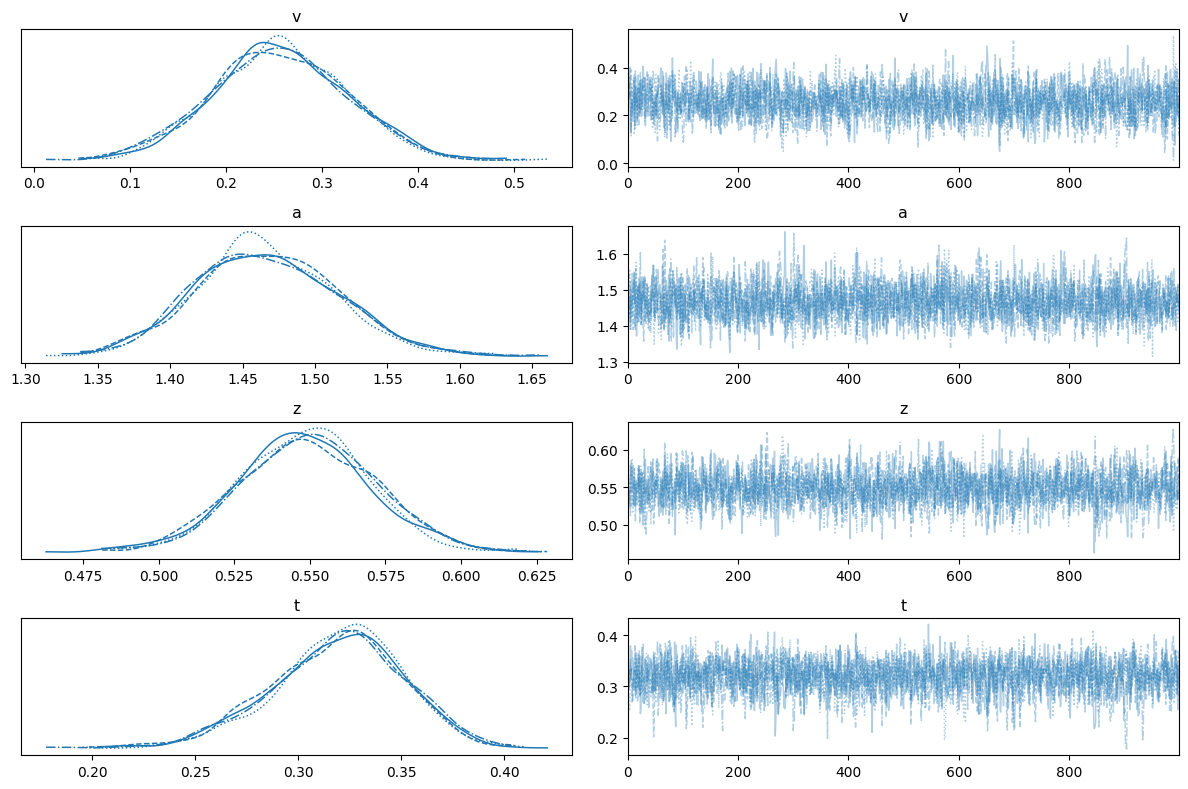

    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
v  0.256  0.069   0.126    0.383      0.001    0.001    2360.0    2646.0   
a  1.467  0.049   1.372    1.553      0.001    0.001    2753.0    2306.0   
z  0.549  0.022   0.507    0.590      0.000    0.000    2266.0    2389.0   
t  0.319  0.032   0.260    0.380      0.001    0.001    2438.0    2281.0   

   r_hat  
v    1.0  
a    1.0  
z    1.0  
t    1.0  

True values: v=0.5, a=1.5, z=0.5, t=0.3


In [9]:
import arviz as az

az.plot_trace(trace, var_names=["v", "a", "z", "t"])
plt.tight_layout()
plt.show()

print(az.summary(trace, var_names=["v", "a", "z", "t"]))
print(f"\nTrue values: v={v_true}, a={a_true}, z={z_true}, t={t_true}")

## Part 3: Comparison with Analytical and LAN DDM Likelihoods

HSSM ships both an **analytical** Wiener first-passage time (WFPT) likelihood and a pre-trained **Likelihood Approximation Network (LAN)** for the DDM.
We can create `pm.Distribution` objects for each using a single call to
`make_distribution_for_supported_model`.

By fitting the **same observed data** with the **same priors**, we get a
three-way comparison:

1. **BayesFlow NRE** -- the ratio estimator we trained in this notebook
2. **HSSM Analytical** -- the exact WFPT likelihood (`loglik_kind="analytical"`)

In [10]:
# One-liner: analytical WFPT distribution for DDM
AnalyticalDDM = make_distribution_for_supported_model(
    "ddm", loglik_kind="analytical", backend="pytensor",
)

# Fit with identical priors and observed data
with pm.Model() as analytical_model:
    v_a = pm.TruncatedNormal("v", mu=0, sigma=1.5, lower=-3.0, upper=3.0)
    a_a = pm.TruncatedNormal("a", mu=1.0, sigma=0.5, lower=0.3, upper=2.5)
    z_a = pm.TruncatedNormal("z", mu=0.5, sigma=0.2, lower=0.1, upper=0.9)
    t_a = pm.TruncatedNormal("t", mu=0.3, sigma=0.3, lower=0.0, upper=2.0)

    obs_a = AnalyticalDDM("obs", v=v_a, a=a_a, z=z_a, t=t_a, observed=x_observed)

    trace_analytical = pm.sample(
        draws=1000,
        nuts_sampler="pymc",
        chains=4,
        cores=1,
        tune=1000,
        initvals={"v": 0.0, "a": 1.0, "z": 0.5, "t": 0.3},
    )

INFO:pymc.sampling.mcmc:Initializing NUTS using jitter+adapt_diag...
/home/radevs/anaconda3/envs/bfjax/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
INFO:pymc.sampling.mcmc:Sequential sampling (4 chains in 1 job)
INFO:pymc.sampling.mcmc:NUTS: [v, a, z, t]


Output()

INFO:pymc.sampling.mcmc:Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 290 seconds.
ERROR:pymc.stats.convergence:There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
INFO:pymc.stats.convergence:The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


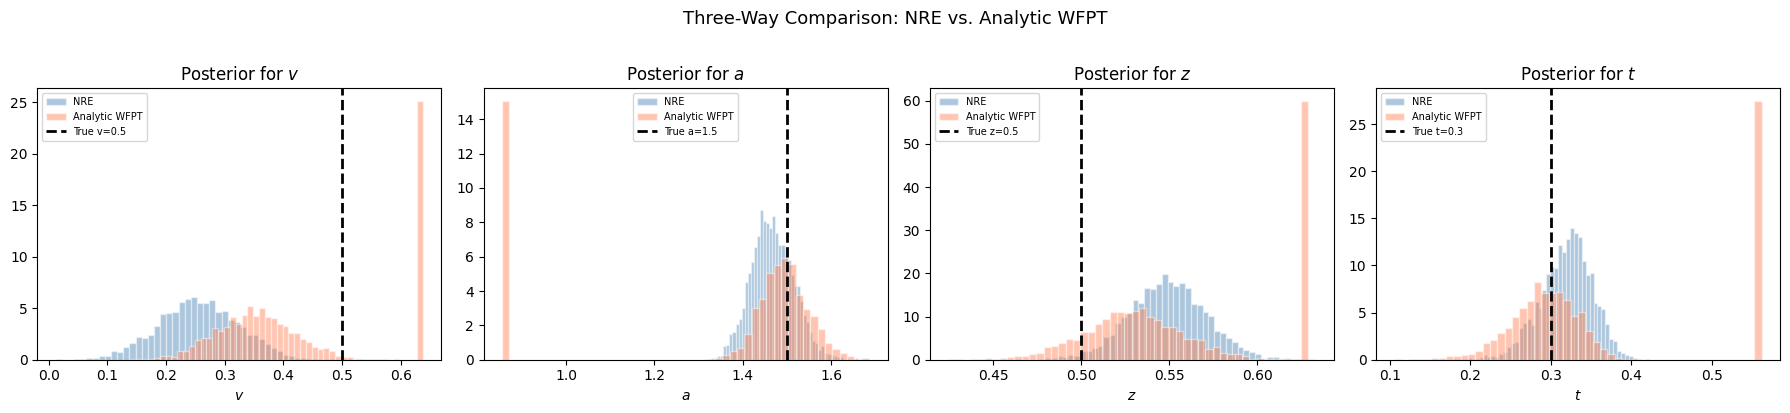

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, (name, true_val) in enumerate([
    ("v", v_true), ("a", a_true), ("z", z_true), ("t", t_true)
]):
    ax = axes[i]

    # BayesFlow ratio estimator posterior
    bf_samples = trace.posterior[name].values.flatten()
    ax.hist(bf_samples, bins=50, density=True, alpha=0.45,
            label="NRE", color="steelblue", edgecolor="white")

    # Analytic DDM posterior
    an_samples = trace_analytical.posterior[name].values.flatten()
    ax.hist(an_samples, bins=50, density=True, alpha=0.45,
            label="Analytic WFPT", color="coral", edgecolor="white")

    # True value
    ax.axvline(true_val, color="black", linestyle="--", linewidth=2,
               label=f"True {name}={true_val}")

    ax.set_xlabel(f"${name}$")
    ax.set_title(f"Posterior for ${name}$")
    ax.legend(fontsize=7)

fig.suptitle("Three-Way Comparison: NRE vs. Analytic WFPT", fontsize=13, y=1.02)
fig.tight_layout()